#### Dependencies

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats

##### Read in the data

In [2]:
# read in the data
hmda_all = pd.read_csv('../data/hmda_all.csv') 
hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_18752\871124796.py:3: DtypeWarning: Columns (26,27,28,29,30,31,32,33,43,44,78,80) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')


## Logistic Regression Models:

### Use the NON Filtered Dataset

### Applicant Ethnicity AE

In [3]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [4]:
list_to_convert = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']

hmda_all_nf[list_to_convert] = hmda_all_nf[list_to_convert].astype(int)
hmda_all_nf['ae_values_1'].unique()

array([0, 1])

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino

In [5]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~
                                            ae_values_1 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                           data=hmda_all_nf)

In [6]:
res_ae = model_logit_ae.fit(maxiter=1000, disp=False)

In [7]:
res_ae.params

Intercept                              2.761815e+00
C(debt_to_income_ratio)[T.30%-<36%]   -3.081547e-03
C(debt_to_income_ratio)[T.36]         -1.192986e-02
C(debt_to_income_ratio)[T.37]         -7.756388e-03
C(debt_to_income_ratio)[T.38]         -1.526521e-02
C(debt_to_income_ratio)[T.39]         -4.343589e-02
C(debt_to_income_ratio)[T.40]         -3.720501e-02
C(debt_to_income_ratio)[T.41]         -6.172733e-02
C(debt_to_income_ratio)[T.42]         -6.168308e-02
C(debt_to_income_ratio)[T.43]         -9.192883e-02
C(debt_to_income_ratio)[T.44]         -7.109921e-02
C(debt_to_income_ratio)[T.45]         -2.569681e-01
C(debt_to_income_ratio)[T.46]         -3.378871e-01
C(debt_to_income_ratio)[T.47]         -3.679518e-01
C(debt_to_income_ratio)[T.48]         -3.268308e-01
C(debt_to_income_ratio)[T.49]         -2.738694e-01
C(debt_to_income_ratio)[T.50%-60%]    -1.537657e+00
C(debt_to_income_ratio)[T.<20%]       -6.033022e-01
C(debt_to_income_ratio)[T.>60%]       -5.119128e+00
C(loan_type)

In [8]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.172097
ae_values_11    0.926419
ae_values_12    0.816099
ae_values_13    0.781161
ae_values_14    0.768162
dtype: float64

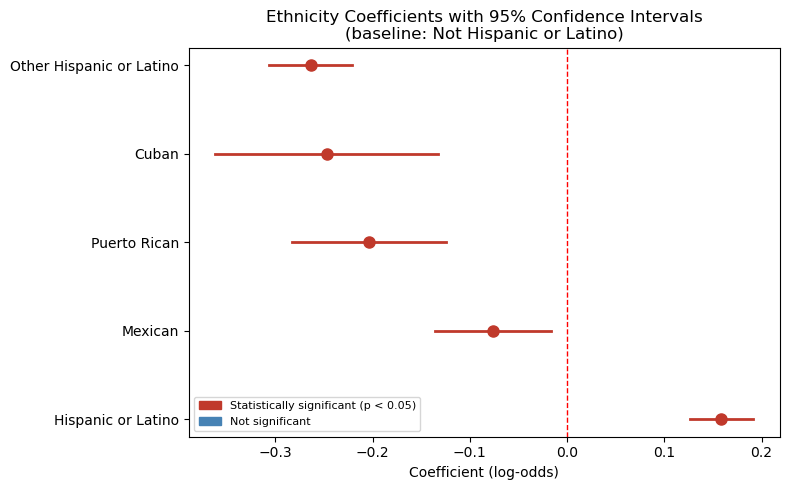

In [9]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

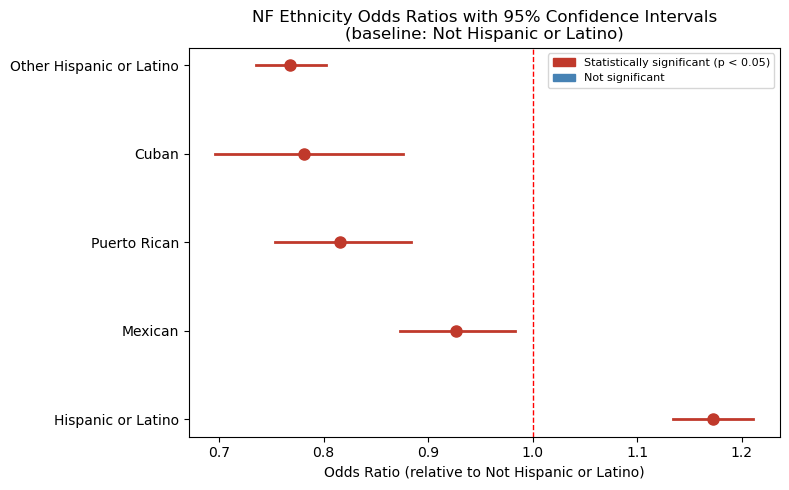

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

#### Model for Applicant Race

In [11]:
model_logit_ar = smf.logit(formula = """approved_originated_or_denied ~ 
                                        ar_values_1 + ar_values_2 + ar_values_3 + 
                                        ar_values_4 + ar_values_21 + ar_values_22 + 
                                        ar_values_23 + ar_values_24 + ar_values_25 + 
                                        ar_values_26 + ar_values_27 + ar_values_41 + 
                                        ar_values_42 + ar_values_43 + ar_values_44 +
                                        income + 
                                        C(debt_to_income_ratio) + 
                                        loan_to_value_ratio +
                                        tract_minority_population_percent + 
                                        C(loan_type)""", 
                           data=hmda_all_nf)

In [12]:
res_ar = model_logit_ar.fit(maxiter=1000, disp=False)

### Predicted Probability for Every Application in dataset

In [13]:
hmda_all_nf['predicted_prob'] = res_ar.predict(hmda_all_nf)
print(hmda_all_nf['predicted_prob'].describe())

count    7.007150e+05
mean     7.939405e-01
std      2.030636e-01
min      5.200637e-18
25%      7.907906e-01
50%      8.666548e-01
75%      8.960960e-01
max      9.699591e-01
Name: predicted_prob, dtype: float64


In [14]:
# Filter to Black or African American applicants
black_df = hmda_all_nf[hmda_all_nf['ar_values_3'] == 1].copy()
white_df = hmda_all_nf[hmda_all_nf['ar_values_5'] == 1].copy()

print(f"Black applicants: {len(black_df):,}")
print(f"White applicants: {len(white_df):,}")

Black applicants: 247,335
White applicants: 401,667


In [15]:
min_apps = 50

# Average predicted probability by lender for Black applicants
lender_black = (
    black_df.groupby('lei')['predicted_prob']
    .agg(['mean', 'count'])
    .reset_index()
)
lender_black.columns = ['lei', 'pred_prob_black', 'n_black']
lender_black = lender_black[lender_black['n_black'] >= min_apps]

# Average predicted probability by lender for white applicants
lender_white = (
    white_df.groupby('lei')['predicted_prob']
    .agg(['mean', 'count'])
    .reset_index()
)
lender_white.columns = ['lei', 'pred_prob_white', 'n_white']

# Merge and calculate gap
lender_combined = lender_black.merge(lender_white, on='lei', how='left')
lender_combined['gap'] = lender_combined['pred_prob_white'] - lender_combined['pred_prob_black']
lender_combined = lender_combined.sort_values('pred_prob_black', ascending=True)

print(f"Lenders with at least {min_apps} Black applications: {len(lender_combined)}")
print(f"\nOverall average predicted probability:")
print(f"  Black applicants: {black_df['predicted_prob'].mean():.1%}")
print(f"  White applicants: {white_df['predicted_prob'].mean():.1%}")
print(f"\nBottom 10 lenders by predicted approval probability for Black applicants:")
print(lender_combined.head(10)[['lei', 'pred_prob_black', 'pred_prob_white', 'gap', 'n_black']].to_string(index=False))

Lenders with at least 50 Black applications: 259

Overall average predicted probability:
  Black applicants: 70.1%
  White applicants: 83.9%

Bottom 10 lenders by predicted approval probability for Black applicants:
                 lei  pred_prob_black  pred_prob_white      gap  n_black
X05BVSK68TQ7YTOSNR22         0.512132         0.664560 0.152428     3117
B4TYDEB6GKMZO031MB27         0.525218         0.705828 0.180610     7368
5493003GQDUH26DNNH17         0.538986         0.737668 0.198682    13330
DRMSV1Q0EKMEXLAU1P80         0.571616         0.736155 0.164539      649
5493000WAJ1FMTFL5D75         0.581126         0.714659 0.133533      111
F28JOQ8OBWCFUYM0UX93         0.588968         0.689838 0.100870       59
AD6GFRVSDT01YPT1CS68         0.594088         0.774742 0.180654     2082
549300KBWX4NV5Q1E376         0.595090         0.705605 0.110515      249
549300KTR1JGH3K6LU06         0.595844         0.737073 0.141229      195
5493005T71YXBHEO2093         0.602144         0.765998

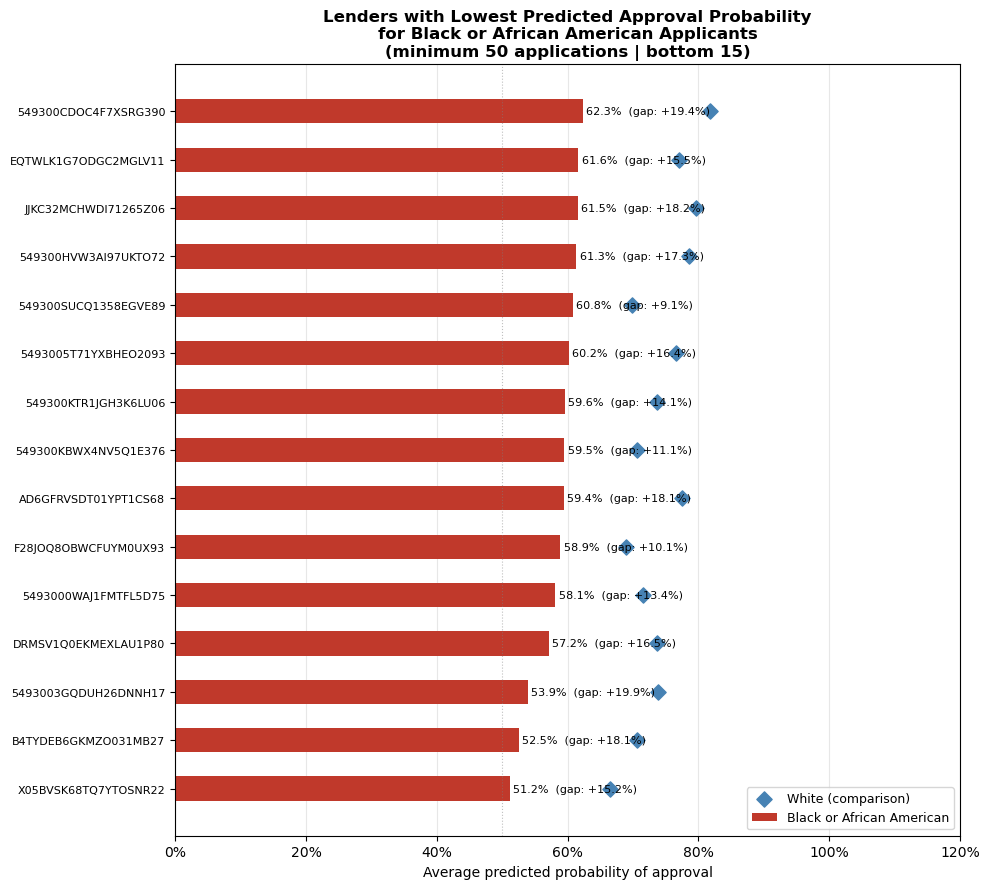

In [16]:
top_n = 15
bottom_lenders = lender_combined.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(5, int(top_n * 0.5 + 2))))

y_pos = range(len(bottom_lenders))

ax.barh(y_pos, bottom_lenders['pred_prob_black'],
        color='#c0392b', height=0.5,
        label='Black or African American', zorder=2)

ax.scatter(bottom_lenders['pred_prob_white'], y_pos,
           color='steelblue', zorder=3, s=60,
           label='White (comparison)', marker='D')

for i, (_, row) in enumerate(bottom_lenders.iterrows()):
    ax.text(row['pred_prob_black'] + 0.005, i,
            f"{row['pred_prob_black']:.1%}  (gap: {row['gap']:+.1%})",
            va='center', fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(bottom_lenders['lei'], fontsize=8)
ax.set_xlabel('Average predicted probability of approval')
ax.set_xlim(0, 1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(f'Lenders with Lowest Predicted Approval Probability\nfor Black or African American Applicants\n(minimum {min_apps} applications | bottom {top_n})',
             fontweight='bold')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/lender_pred_prob_black_applicants.png', bbox_inches='tight', dpi=150)
plt.show()

In [17]:
aus_labels = {
    1: "Desktop Underwriter (DU/DO)",
    2: "Loan Prospector / Loan Product Advisor (LP/LPA)",
    3: "Technology Open to Approved Lenders (TOTAL)",
    4: "Guaranteed Underwriting System (GUS)",
    5: "Other",
    7: "Internal Proprietary System",
}

aus_cols = ['aus-1', 'aus-2', 'aus-3', 'aus-4', 'aus-5']

# Melt AUS columns for Black applicants
aus_black = black_df[['predicted_prob'] + aus_cols].melt(
    id_vars=['predicted_prob'],
    value_vars=aus_cols,
    var_name='aus_col',
    value_name='aus_code'
)
aus_black = aus_black.dropna(subset=['aus_code'])
aus_black['aus_code'] = pd.to_numeric(aus_black['aus_code'], errors='coerce')
aus_black = aus_black[~aus_black['aus_code'].isin([6, 1111])]
aus_black = aus_black.dropna(subset=['aus_code'])
aus_black['aus_code'] = aus_black['aus_code'].astype(int)

# Melt AUS columns for White applicants
aus_white = white_df[['predicted_prob'] + aus_cols].melt(
    id_vars=['predicted_prob'],
    value_vars=aus_cols,
    var_name='aus_col',
    value_name='aus_code'
)
aus_white = aus_white.dropna(subset=['aus_code'])
aus_white['aus_code'] = pd.to_numeric(aus_white['aus_code'], errors='coerce')
aus_white = aus_white[~aus_white['aus_code'].isin([6, 1111])]
aus_white = aus_white.dropna(subset=['aus_code'])
aus_white['aus_code'] = aus_white['aus_code'].astype(int)

# Average predicted probability by AUS
aus_stats_black = aus_black.groupby('aus_code')['predicted_prob'].agg(['mean', 'count']).reset_index()
aus_stats_black.columns = ['aus_code', 'pred_prob_black', 'n_black']

aus_stats_white = aus_white.groupby('aus_code')['predicted_prob'].agg(['mean', 'count']).reset_index()
aus_stats_white.columns = ['aus_code', 'pred_prob_white', 'n_white']

aus_combined = aus_stats_black.merge(aus_stats_white, on='aus_code', how='left')
aus_combined['aus_name'] = aus_combined['aus_code'].map(aus_labels).fillna(aus_combined['aus_code'].astype(str))
aus_combined['gap'] = aus_combined['pred_prob_white'] - aus_combined['pred_prob_black']
aus_combined = aus_combined[aus_combined['n_black'] >= 20]
aus_combined = aus_combined.sort_values('pred_prob_black', ascending=True)

print("AUS Predicted Approval Probabilities — Black vs. White Applicants:")
print(aus_combined[['aus_name', 'pred_prob_black', 'pred_prob_white', 'gap', 'n_black']].to_string(index=False))

AUS Predicted Approval Probabilities — Black vs. White Applicants:
                                       aus_name  pred_prob_black  pred_prob_white      gap  n_black
                                          Other         0.558838         0.773747 0.214910     9488
                    Internal Proprietary System         0.610566         0.751706 0.141140     3492
    Technology Open to Approved Lenders (TOTAL)         0.731175         0.853421 0.122246    38649
Loan Prospector / Loan Product Advisor (LP/LPA)         0.739398         0.857713 0.118315    40685
                    Desktop Underwriter (DU/DO)         0.742537         0.861576 0.119038   110007
           Guaranteed Underwriting System (GUS)         0.829177         0.909965 0.080788      497


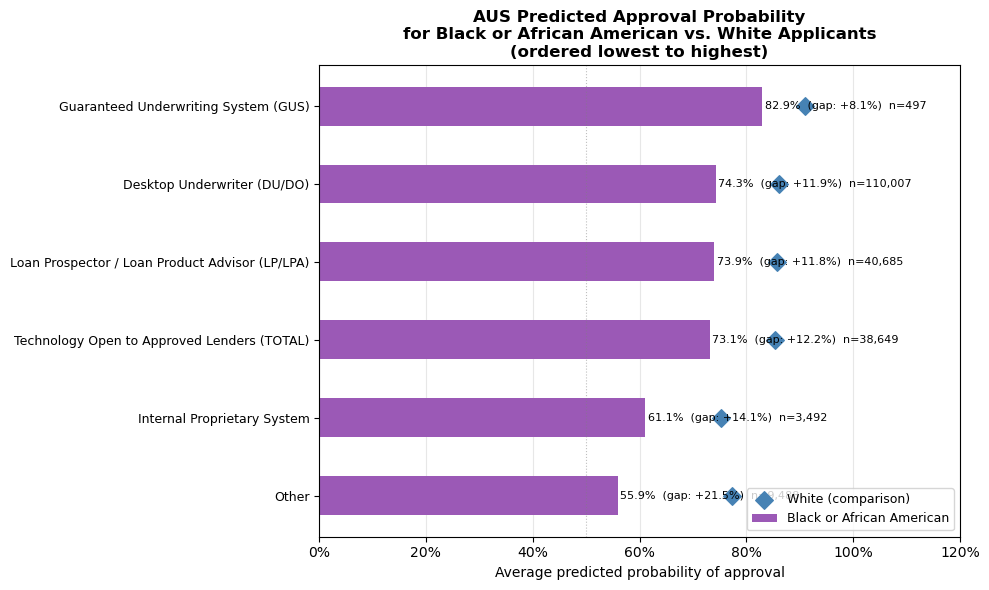


Key finding:
Highest predicted probability: 82.9% — Guaranteed Underwriting System (GUS)
Lowest predicted probability:  55.9% — Other
Gap between best and worst AUS: 27.0%


In [18]:
fig, ax = plt.subplots(figsize=(10, max(4, int(len(aus_combined) * 0.8 + 1.5))))

y_pos = range(len(aus_combined))

ax.barh(y_pos, aus_combined['pred_prob_black'],
        color='#9b59b6', height=0.5,
        label='Black or African American', zorder=2)

ax.scatter(aus_combined['pred_prob_white'], y_pos,
           color='steelblue', zorder=3, s=80,
           label='White (comparison)', marker='D')

for i, (_, row) in enumerate(aus_combined.iterrows()):
    ax.text(row['pred_prob_black'] + 0.005, i,
            f"{row['pred_prob_black']:.1%}  (gap: {row['gap']:+.1%})  n={int(row['n_black']):,}",
            va='center', fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(aus_combined['aus_name'], fontsize=9)
ax.set_xlabel('Average predicted probability of approval')
ax.set_xlim(0, 1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title('AUS Predicted Approval Probability\nfor Black or African American vs. White Applicants\n(ordered lowest to highest)',
             fontweight='bold')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/aus_pred_prob_black_applicants.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nKey finding:")
print(f"Highest predicted probability: {aus_combined.iloc[-1]['pred_prob_black']:.1%} — {aus_combined.iloc[-1]['aus_name']}")
print(f"Lowest predicted probability:  {aus_combined.iloc[0]['pred_prob_black']:.1%} — {aus_combined.iloc[0]['aus_name']}")
print(f"Gap between best and worst AUS: {aus_combined.iloc[-1]['pred_prob_black'] - aus_combined.iloc[0]['pred_prob_black']:.1%}")

In [19]:
# Filter to specific lender
lender_filter = hmda_all_nf[hmda_all_nf['lei'] == '5493003B2LEGQHDWRN55'].copy()

print(f"Total applications at this lender: {len(lender_filter):,}")
print(f"\nApproval rate by race group:")
print(f"{'Group':<45} {'Approval Rate':>15} {'Applications':>15}")
print("-" * 75)

race_cols = {
    'ar_values_1':  'American Indian or Alaska Native',
    'ar_values_2':  'Asian',
    'ar_values_3':  'Black or African American',
    'ar_values_4':  'Native Hawaiian or Other Pacific Islander',
    'ar_values_5':  'White',
    'ar_values_21': 'Asian Indian',
    'ar_values_22': 'Chinese',
    'ar_values_23': 'Filipino',
    'ar_values_24': 'Japanese',
    'ar_values_25': 'Korean',
    'ar_values_26': 'Vietnamese',
    'ar_values_27': 'Other Asian',
    'ar_values_41': 'Native Hawaiian',
    'ar_values_42': 'Guamanian or Chamorro',
    'ar_values_43': 'Samoan',
    'ar_values_44': 'Other Pacific Islander',
}

for col, label in race_cols.items():
    if col in lender_filter.columns:
        group = lender_filter[lender_filter[col] == 1]
        if len(group) > 0:
            approval_rate = group['approved_originated_or_denied'].mean()
            print(f"{label:<45} {approval_rate:>14.1%} {len(group):>15,}")

Total applications at this lender: 46

Approval rate by race group:
Group                                           Approval Rate    Applications
---------------------------------------------------------------------------
Asian                                                 100.0%               3
Black or African American                              45.0%              20
White                                                  84.2%              19
Asian Indian                                          100.0%               3
Vietnamese                                            100.0%               1
Other Pacific Islander                                100.0%               1


#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino
#### Include open_end_line_of_credit

In [20]:
model_logit_ae_nf_oelc = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio + 
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(open_end_line_of_credit)""", 
                              data=hmda_all_nf)

In [21]:
res_ae = model_logit_ae_nf_oelc.fit(maxiter=1000, disp=False)

C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.215183
ae_values_11    0.948121
ae_values_12    0.807411
ae_values_13    0.784403
ae_values_14    0.737709
dtype: float64

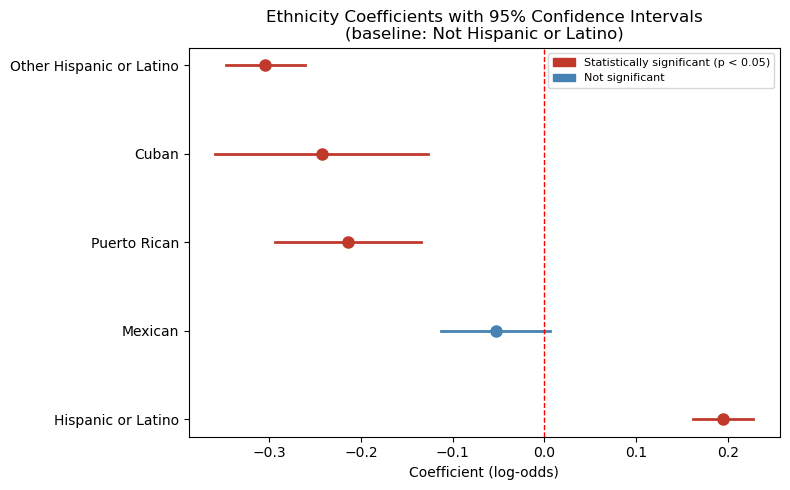

In [23]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

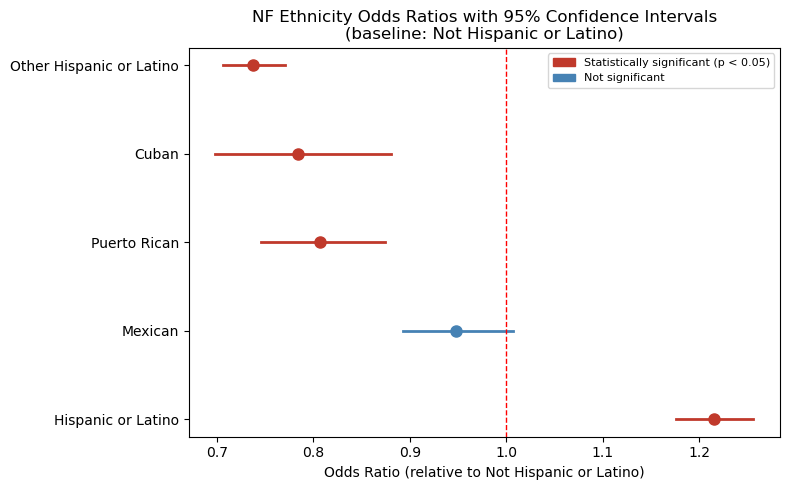

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

#### Create Hispanic vs. Not Hispanic without OELC

In [25]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [26]:
hmda_hispanic_not_hispanic = hmda_all_nf[~hmda_all_nf['applicant_ethnicity-1'].isin([3, 4])]

In [27]:
# hmda columns
ethnicity_cols = ['applicant_ethnicity-1', 'applicant_ethnicity-2', 'applicant_ethnicity-3',
                  'applicant_ethnicity-4', 'applicant_ethnicity-5']

hispanic_nums = [1, 11, 12, 13, 14]

# indicator columns for each hispanic subcategory --> one per code/num
for num in hispanic_nums:
    hmda_hispanic_not_hispanic[f'ae_values_{num}'] = (hmda_hispanic_not_hispanic[ethnicity_cols] == num).any(axis=1)

# overall hispanic indicator
hmda_hispanic_not_hispanic['is_hispanic'] = hmda_hispanic_not_hispanic[[f'ae_values_{num}' for num in hispanic_nums]].any(axis=1)

# not hispanic indicator
hmda_hispanic_not_hispanic['not_hispanic'] = hmda_hispanic_not_hispanic['ae_values_2']

In [28]:
model_logit_ae_h = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            is_hispanic + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                             data=hmda_all_nf)

In [29]:
res_ae_h = model_logit_ae_h.fit(maxiter=1000, disp=False)

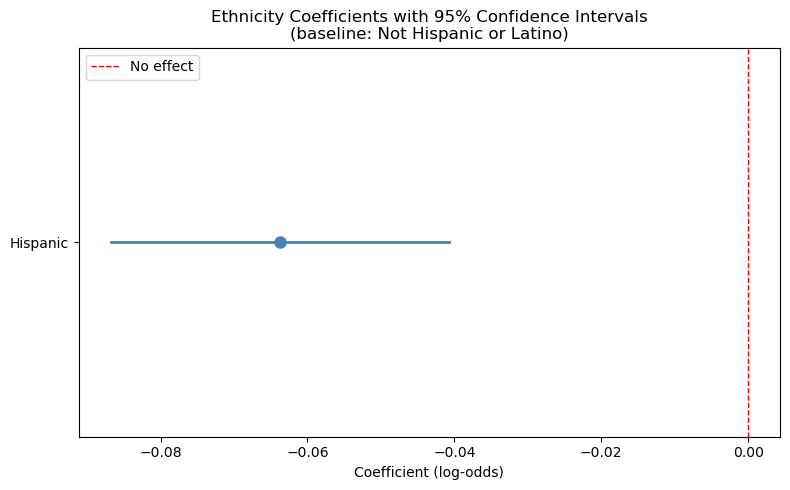

In [30]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['is_hispanic']
labels = ['Hispanic']

coefs_h = res_ae_h.params[ethnicity_vars]
conf_h = res_ae_h.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_h.loc[var, 0], conf_h.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_h[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_hispanic_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

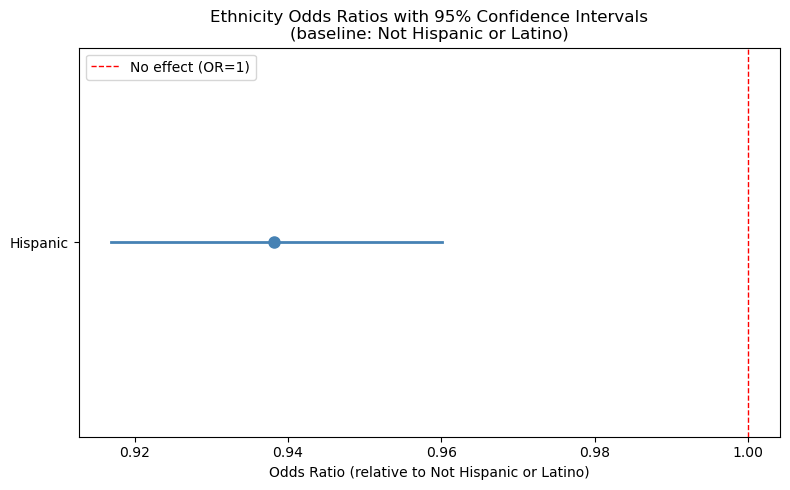

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_h)
conf_or = np.exp(conf_h)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_hispanic_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

### Use the Filtered Dataset for the same Logistic Regression:

### Applicant Ethnicity AE

In [32]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino

In [33]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~
                                            ae_values_1 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                           data=hmda_all)

In [34]:
res_ae = model_logit_ae.fit(maxiter=1000, disp=False)

In [35]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.176211
ae_values_11    1.055665
ae_values_12    0.932897
ae_values_13    1.104862
ae_values_14    0.732207
dtype: float64

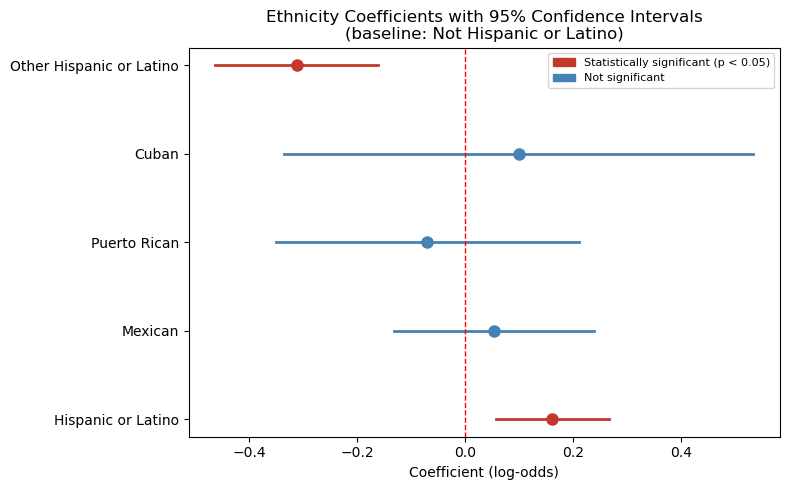

In [36]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

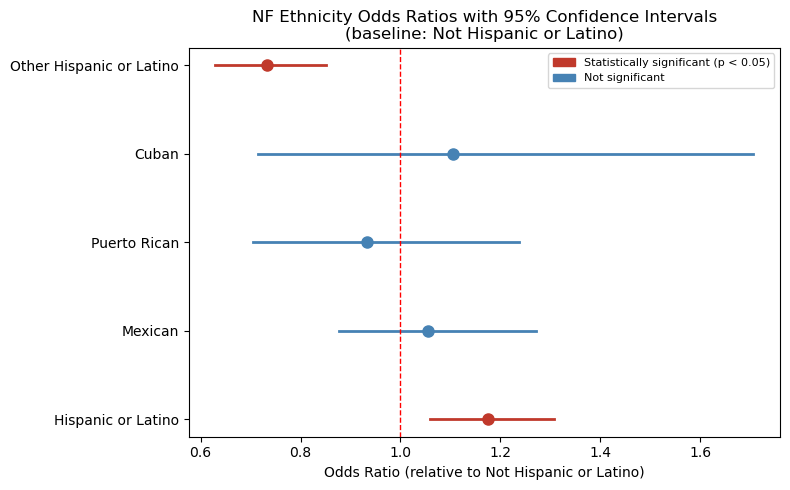

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino
#### Include open_end_line_of_credit

In [38]:
model_logit_ae_oelc = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio + 
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(open_end_line_of_credit) + 
                                            applicant_age + 
                                            gender""", 
                              data=hmda_all)

In [39]:
res_ae = model_logit_ae_oelc.fit(maxiter=1000, disp=False)

In [40]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.176211
ae_values_11    1.055665
ae_values_12    0.932897
ae_values_13    1.104862
ae_values_14    0.732207
dtype: float64

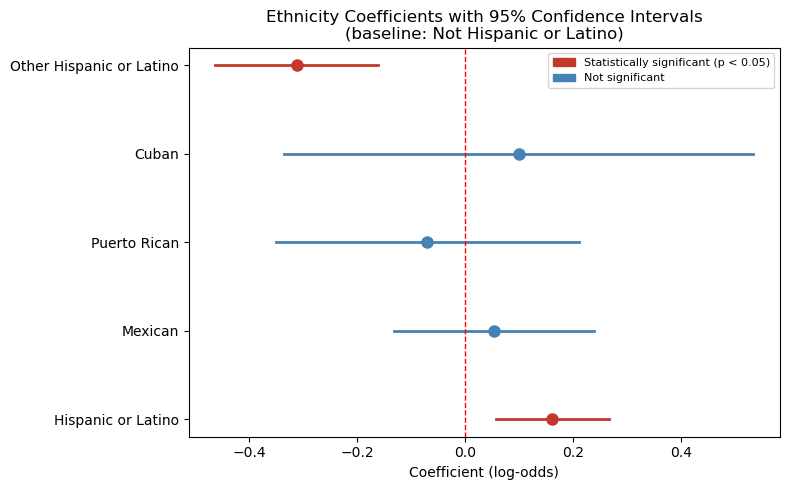

In [41]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

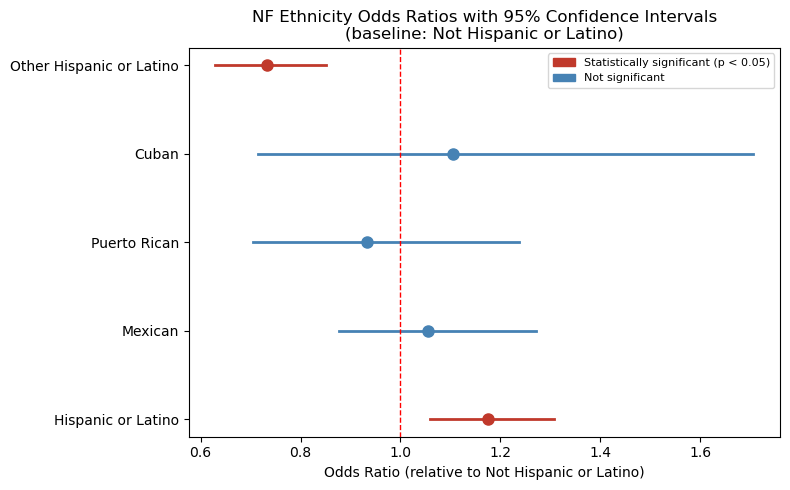

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, eth_patch], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_oelc.png', bbox_inches='tight')
plt.show()

#### Create Hispanic vs. Not Hispanic without OELC

In [43]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [44]:
hmda_all = hmda_all[~hmda_all['applicant_ethnicity-1'].isin([3, 4])]

In [45]:
# hmda columns
ethnicity_cols = ['applicant_ethnicity-1', 'applicant_ethnicity-2', 'applicant_ethnicity-3',
                  'applicant_ethnicity-4', 'applicant_ethnicity-5']

hispanic_nums = [1, 11, 12, 13, 14]

# indicator columns for each hispanic subcategory --> one per code
for num in hispanic_nums:
    hmda_all[f'ae_values_{num}'] = (hmda_all[ethnicity_cols] == num).any(axis=1)

# overall hispanic indicator
hmda_all['is_hispanic'] = hmda_all[[f'ae_values_{num}' for num in hispanic_nums]].any(axis=1)

# not hispanic indicator
hmda_all['not_hispanic'] = hmda_all['ae_values_2']

C:\Users\Cat\AppData\Local\Temp\ipykernel_18752\75831961.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_all[f'ae_values_{num}'] = (hmda_all[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\Temp\ipykernel_18752\75831961.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_all[f'ae_values_{num}'] = (hmda_all[ethnicity_cols] == num).any(axis=1)
C:\Users\Cat\AppData\Local\Temp\ipykernel_18752\75831961.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [46]:
model_logit_ae_h_f = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            is_hispanic + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                             data=hmda_all)

In [47]:
res_ae_h = model_logit_ae_h_f.fit(maxiter=1000, disp=False)

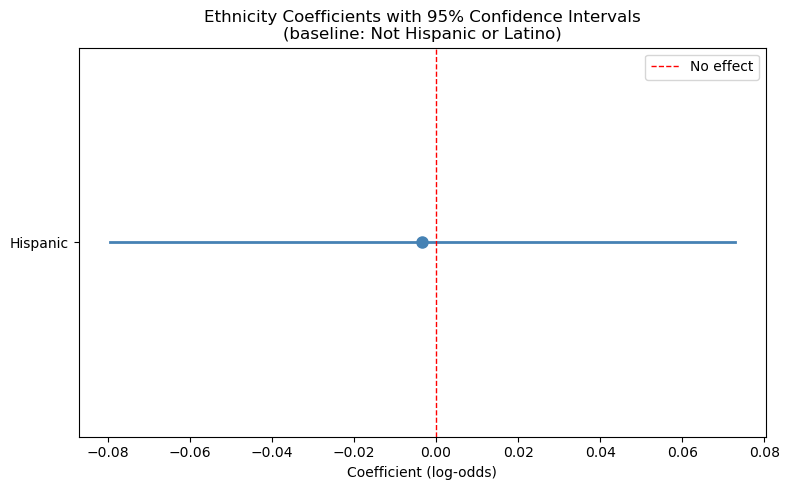

In [48]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['is_hispanic[T.True]']
labels = ['Hispanic']

coefs_h = res_ae_h.params[ethnicity_vars]
conf_h = res_ae_h.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_h.loc[var, 0], conf_h.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_h[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/App_Ethnicity_hispanic_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

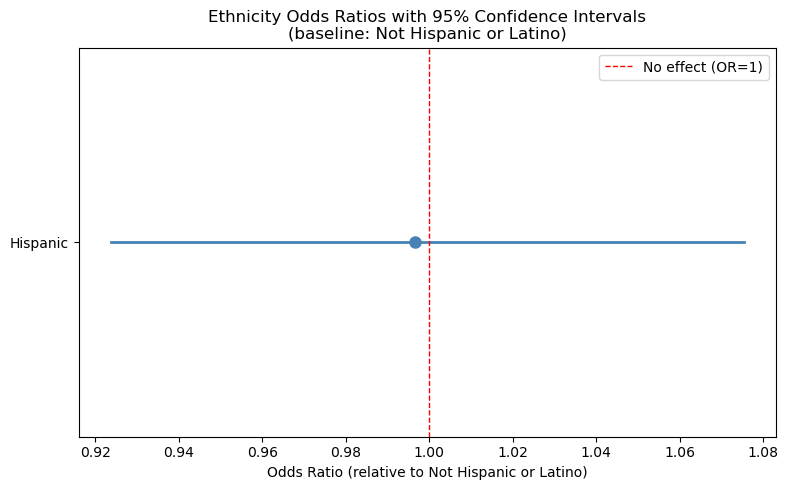

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_h)
conf_or = np.exp(conf_h)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/App_Ethnicity_hispanic_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()